In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing   
from sklearn.model_selection import train_test_split
from sklearn.cluster import k_means
from sklearn.impute import SimpleImputer

In [7]:
df = pd.read_csv('sales_dataset_email.csv')

In [22]:
df.head(60)

,CustomerID,Name,Email,Age,Gender,Location,PurchaseHistory,BrowsingBehavior,AmountSpent,MembershipTier
0,439415,Taylor Brown,iyevwvc@xpvsc.com,46.0,Female,Chicago,Smartphone,Sports,455.77,Gold
1,391407,Casey Garcia,rcckyzo@zxksq.com,43.0,Female,Chicago,Laptop,Beauty & Health,51.28,Gold
2,547997,Casey Martinez,dymvmaj@cgiux.com,46.0,Non-binary,Berlin,Tablet,Fashion,3651.59,Platinum
3,814863,John Johnson,jqjtror@pgeng.com,56.0,Female,Los Angeles,Printer,Fashion,4504.26,Silver
4,769435,Morgan Brown,uhldvtd@wlntn.com,43.0,Non-binary,Toronto,Headphones,Fashion,3921.94,Silver
5,681944,Alex Miller,ocgghqh@gglgd.com,67.0,Non-binary,Berlin,[],Toys,2304.62,Bronze
6,789531,Taylor Miller,hgiylir@exdaa.com,46.0,Female,Sydney,Keyboard,[],1427.31,Silver
7,296066,Jane Garcia,unknown@example.com,24.0,NaN,Berlin,Keyboard,Books,3067.58,Basic
8,502824,Skyler Martinez,gbvrrwv@tvmkm.com,50.0,Non-binary,Sydney,Printer,Toys,3703.79,Bronze
9,596776,Taylor Smith,btlcnye@iceiy.com,25.0,Non-binary,Los Angeles,[],[],4725.37,Bronze


In [11]:
df.describe()

,CustomerID,Age,AmountSpent
count,514309.000000,462948.000000,488669.000000
mean,550310.355819,46.479624,2507.648729
std,259931.095415,16.724177,1438.175110
min,100000.000000,18.000000,20.010000
25%,325174.000000,32.000000,1262.450000
50%,550293.000000,46.000000,2507.960000
75%,775431.000000,61.000000,3754.400000
max,999999.000000,75.000000,4999.990000


In [15]:
df['Email'].fillna('unknown@example.com', inplace=True)

# Impute missing values in 'Age' with the median age
imputer = SimpleImputer(strategy='median')
df['Age'] = imputer.fit_transform(df[['Age']])

# Fill missing values in 'PurchaseHistory' and 'BrowsingBehavior' with empty lists
df['PurchaseHistory'].fillna('[]', inplace=True)
df['BrowsingBehavior'].fillna('[]', inplace=True)


# Impute missing values in 'AmountSpent' with the median amount spent
df['AmountSpent'] = imputer.fit_transform(df[['AmountSpent']])

# Fill missing values in 'MembershipTier' with a default value
df['MembershipTier'].fillna('Basic', inplace=True)

/var/folders/_7/wbb8p5rn1jxcc1d45rrn7qqh0000gn/T/ipykernel_58804/2753302742.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['PurchaseHistory'].fillna('[]', inplace=True)
/var/folders/_7/wbb8p5rn1jxcc1d45rrn7qqh0000gn/T/ipykernel_58804/2753302742.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alwa

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 514309 entries, 0 to 514308
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   CustomerID        514309 non-null  int64  
 1   Name              514309 non-null  object 
 2   Email             514309 non-null  object 
 3   Age               514309 non-null  float64
 4   Gender            462743 non-null  object 
 5   Location          514309 non-null  object 
 6   PurchaseHistory   514309 non-null  object 
 7   BrowsingBehavior  514309 non-null  object 
 8   AmountSpent       514309 non-null  float64
 9   MembershipTier    514309 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 39.2+ MB


In [25]:
print(df['BrowsingBehavior'].value_counts())
print(df['PurchaseHistory'].value_counts())
print(df['MembershipTier'].value_counts())
print(df['Location'].value_counts())


BrowsingBehavior
Sports             66524
Beauty & Health    66490
Home & Garden      66199
Toys               66175
Fashion            66159
Electronics        66079
Books              65630
[]                 51053
Name: count, dtype: int64
PurchaseHistory
[]            51728
Smartwatch    46545
Mouse         46477
Monitor       46365
Printer       46328
Smartphone    46245
Keyboard      46233
Laptop        46192
Camera        46191
Headphones    46036
Tablet        45969
Name: count, dtype: int64
MembershipTier
Bronze      122543
Gold        122264
Silver      122193
Platinum    121723
Basic        25586
Name: count, dtype: int64
Location
Phoenix        57522
London         57415
Chicago        57368
Berlin         57201
Sydney         57119
New York       57068
Los Angeles    56990
Houston        56961
Toronto        56665
Name: count, dtype: int64


In [26]:
membership_medians = df.groupby('MembershipTier')['AmountSpent'].median().sort_values(ascending=False)

In [27]:
membership_medians

MembershipTier
Basic       2507.96
Bronze      2507.96
Gold        2507.96
Platinum    2507.96
Silver      2507.96
Name: AmountSpent, dtype: float64

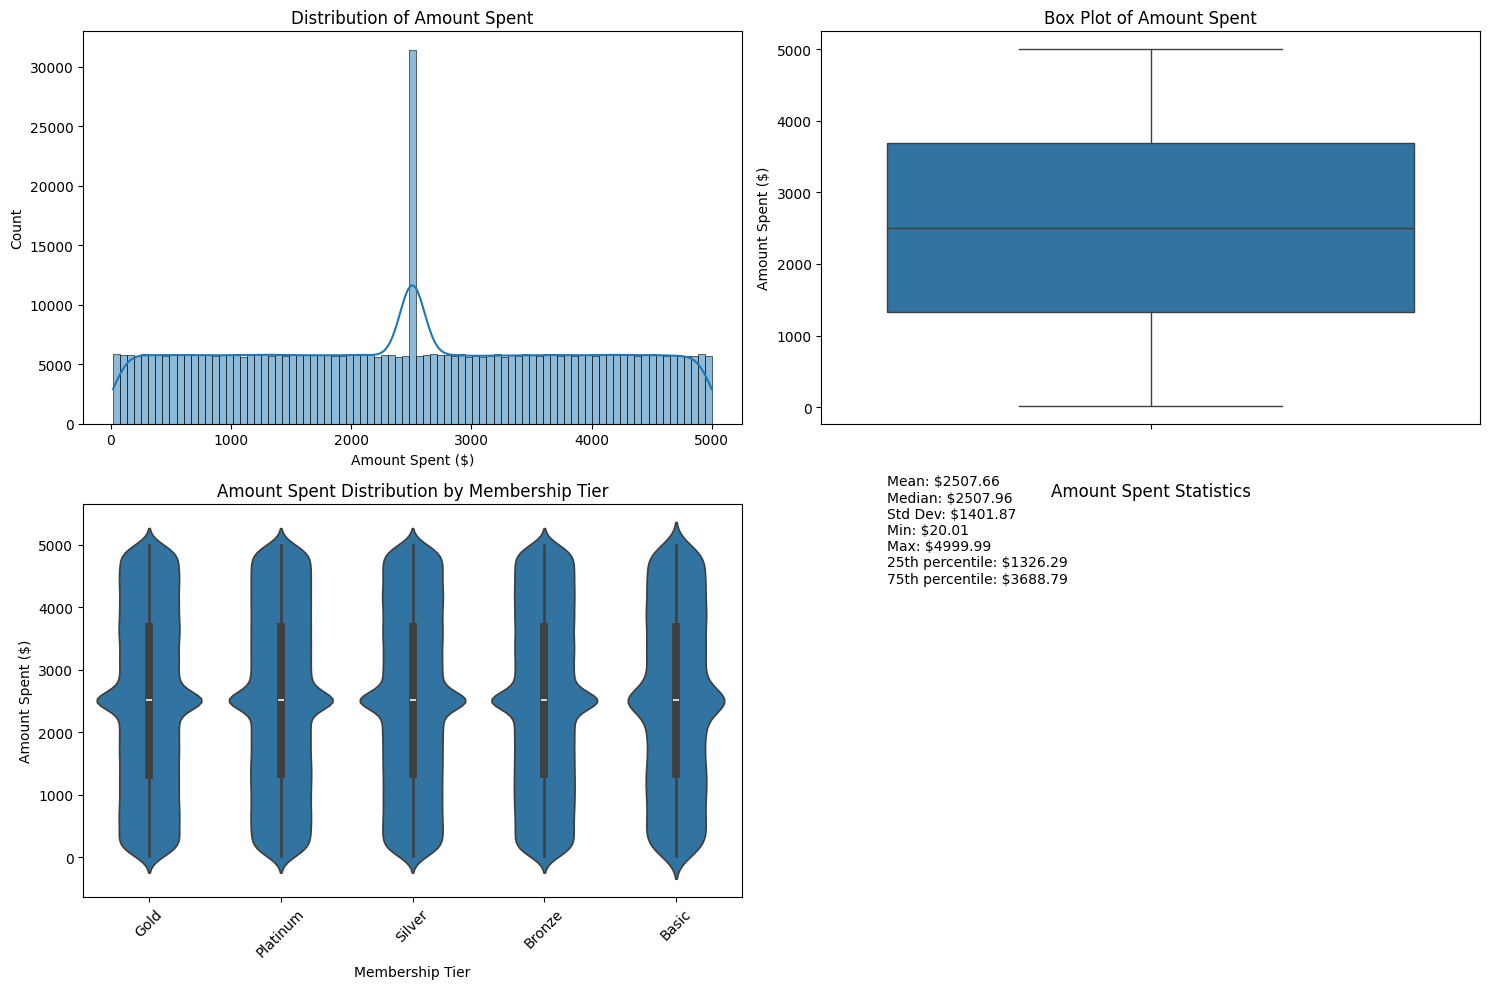


Detailed Statistics for Amount Spent:
count    514309.000000
mean       2507.664247
std        1401.867860
min          20.010000
25%        1326.290000
50%        2507.960000
75%        3688.790000
max        4999.990000
Name: AmountSpent, dtype: float64


In [28]:
# Create a figure with multiple subplots to show different aspects of AmountSpent
plt.figure(figsize=(15, 10))

# 1. Histogram with KDE
plt.subplot(2, 2, 1)
sns.histplot(data=df, x='AmountSpent', kde=True)
plt.title('Distribution of Amount Spent')
plt.xlabel('Amount Spent ($)')
plt.ylabel('Count')

# 2. Box Plot
plt.subplot(2, 2, 2)
sns.boxplot(y=df['AmountSpent'])
plt.title('Box Plot of Amount Spent')
plt.ylabel('Amount Spent ($)')

# 3. Violin Plot by Membership Tier
plt.subplot(2, 2, 3)
sns.violinplot(x='MembershipTier', y='AmountSpent', data=df)
plt.xticks(rotation=45)
plt.title('Amount Spent Distribution by Membership Tier')
plt.xlabel('Membership Tier')
plt.ylabel('Amount Spent ($)')

# 4. Basic Statistics
plt.subplot(2, 2, 4)
stats = df['AmountSpent'].describe()
plt.text(0.1, 0.8, f"Mean: ${stats['mean']:.2f}\n"
         f"Median: ${stats['50%']:.2f}\n"
         f"Std Dev: ${stats['std']:.2f}\n"
         f"Min: ${stats['min']:.2f}\n"
         f"Max: ${stats['max']:.2f}\n"
         f"25th percentile: ${stats['25%']:.2f}\n"
         f"75th percentile: ${stats['75%']:.2f}")
plt.axis('off')
plt.title('Amount Spent Statistics')

plt.tight_layout()
plt.show()

# Print the exact statistics
print("\nDetailed Statistics for Amount Spent:")
print(df['AmountSpent'].describe())

In [29]:
# Drop the MembershipTier column
df = df.drop('MembershipTier', axis=1)

# Verify the column has been dropped
print("Remaining columns:", df.columns.tolist())

Remaining columns: ['CustomerID', 'Name', 'Email', 'Age', 'Gender', 'Location', 'PurchaseHistory', 'BrowsingBehavior', 'AmountSpent']



Membership Tier Distribution:
MembershipTier
Bronze      102863
Silver      102862
Platinum    102862
Diamond     102862
Gold        102860
Name: count, dtype: int64

Spending Ranges for Each Tier:
                    min      max
MembershipTier                  
Bronze            20.01  1065.29
Silver          1065.30  2111.45
Gold            2111.46  2900.52
Platinum        2900.53  3951.03
Diamond         3951.04  4999.99


/var/folders/_7/wbb8p5rn1jxcc1d45rrn7qqh0000gn/T/ipykernel_58804/900734443.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_ranges = df.groupby('MembershipTier')['AmountSpent'].agg(['min', 'max']).round(2)


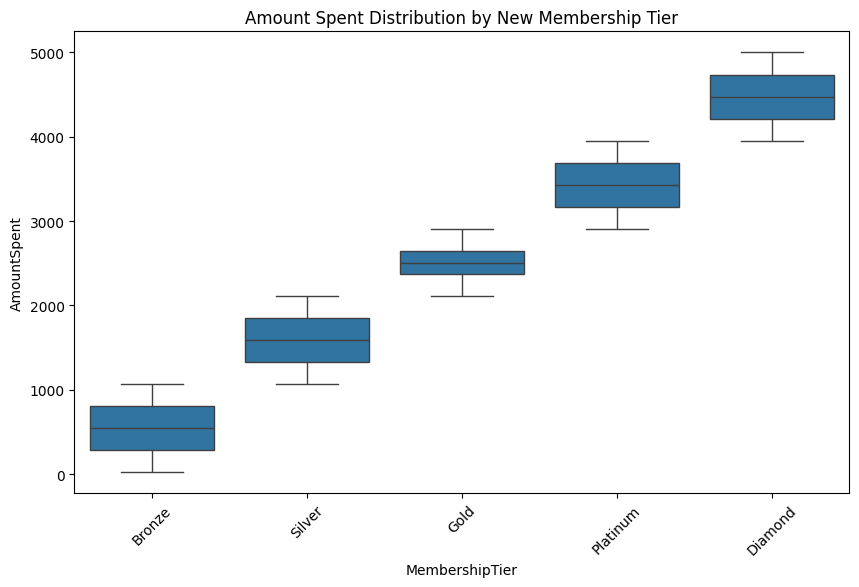

In [30]:
# Create membership tiers based on AmountSpent using percentiles
df['MembershipTier'] = pd.qcut(df['AmountSpent'], q=5, labels=['Bronze', 'Silver', 'Gold', 'Platinum', 'Diamond'])

# Display the distribution of new membership tiers
print("\nMembership Tier Distribution:")
print(df['MembershipTier'].value_counts())

# Show the spending ranges for each tier
print("\nSpending Ranges for Each Tier:")
tier_ranges = df.groupby('MembershipTier')['AmountSpent'].agg(['min', 'max']).round(2)
print(tier_ranges)

# Optional: Visualize the new tiers
plt.figure(figsize=(10, 6))
sns.boxplot(x='MembershipTier', y='AmountSpent', data=df)
plt.title('Amount Spent Distribution by New Membership Tier')
plt.xticks(rotation=45)
plt.show()

In [31]:
df

,CustomerID,Name,Email,Age,Gender,Location,PurchaseHistory,BrowsingBehavior,AmountSpent,MembershipTier
0,439415,Taylor Brown,iyevwvc@xpvsc.com,46.0,Female,Chicago,Smartphone,Sports,455.77,Bronze
1,391407,Casey Garcia,rcckyzo@zxksq.com,43.0,Female,Chicago,Laptop,Beauty & Health,51.28,Bronze
2,547997,Casey Martinez,dymvmaj@cgiux.com,46.0,Non-binary,Berlin,Tablet,Fashion,3651.59,Platinum
3,814863,John Johnson,jqjtror@pgeng.com,56.0,Female,Los Angeles,Printer,Fashion,4504.26,Diamond
4,769435,Morgan Brown,uhldvtd@wlntn.com,43.0,Non-binary,Toronto,Headphones,Fashion,3921.94,Platinum
...,...,...,...,...,...,...,...,...,...,...
514304,207951,Morgan Davis,lvelckx@eoski.com,33.0,Male,Berlin,Monitor,Sports,150.92,Bronze
514305,932761,Jane Miller,lrqudun@mwyrw.com,58.0,Female,Sydney,Camera,Sports,4688.65,Diamond
514306,792017,Taylor Williams,fplgbcw@oimoc.com,46.0,Male,New York,Mouse,Fashion,1254.62,Silver
514307,457370,Chris Martinez,unknown@example.com,52.0,Female,Los Angeles,Tablet,Books,2098.87,Silver


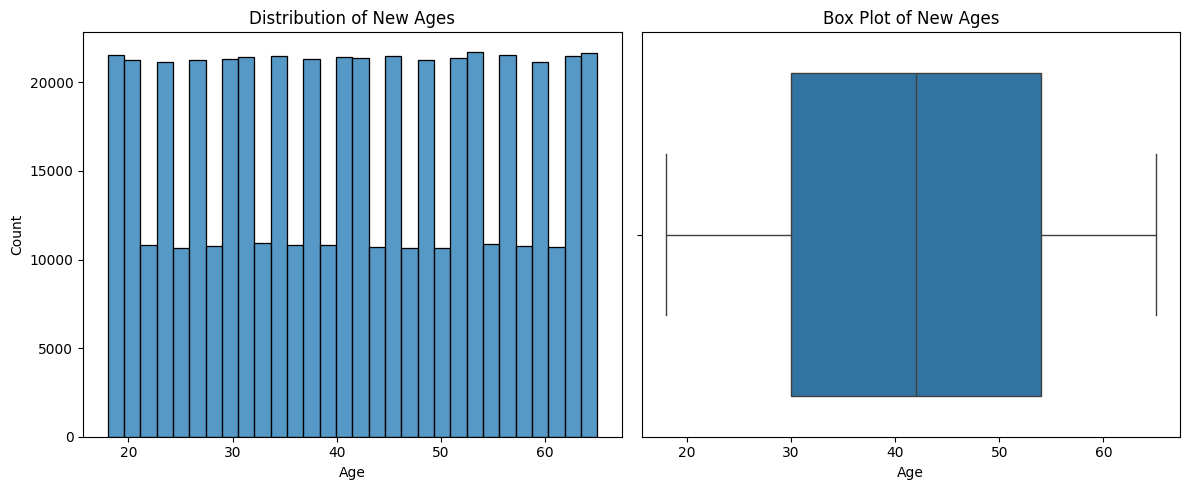


Age Statistics:
count    514309.00
mean         41.52
std          13.85
min          18.00
25%          30.00
50%          42.00
75%          54.00
max          65.00
Name: Age, dtype: float64


In [34]:
# Drop the existing Age column
df = df.drop('Age', axis=1)

# Create new Age column with random values between 18-65
np.random.seed(42)  # for reproducibility
df['Age'] = np.random.randint(18, 66, size=len(df))

# Verify the new age distribution
plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='Age', bins=30)
plt.title('Distribution of New Ages')
plt.xlabel('Age')
plt.ylabel('Count')

# Box plot
plt.subplot(1, 2, 2)
sns.boxplot(x=df['Age'])
plt.title('Box Plot of New Ages')
plt.xlabel('Age')

plt.tight_layout()
plt.show()

# Print basic statistics of the new Age column
print("\nAge Statistics:")
print(df['Age'].describe().round(2))

/var/folders/_7/wbb8p5rn1jxcc1d45rrn7qqh0000gn/T/ipykernel_58804/2305607323.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_stats = df.groupby('MembershipTier')['Age'].agg(['min', 'max', 'mean', 'median']).round(2)



Age Statistics by Membership Tier:
                min  max   mean  median
MembershipTier                         
Bronze           18   65  41.50    42.0
Silver           18   65  41.54    42.0
Gold             18   65  41.60    42.0
Platinum         18   65  41.51    41.0
Diamond          18   65  41.46    41.0


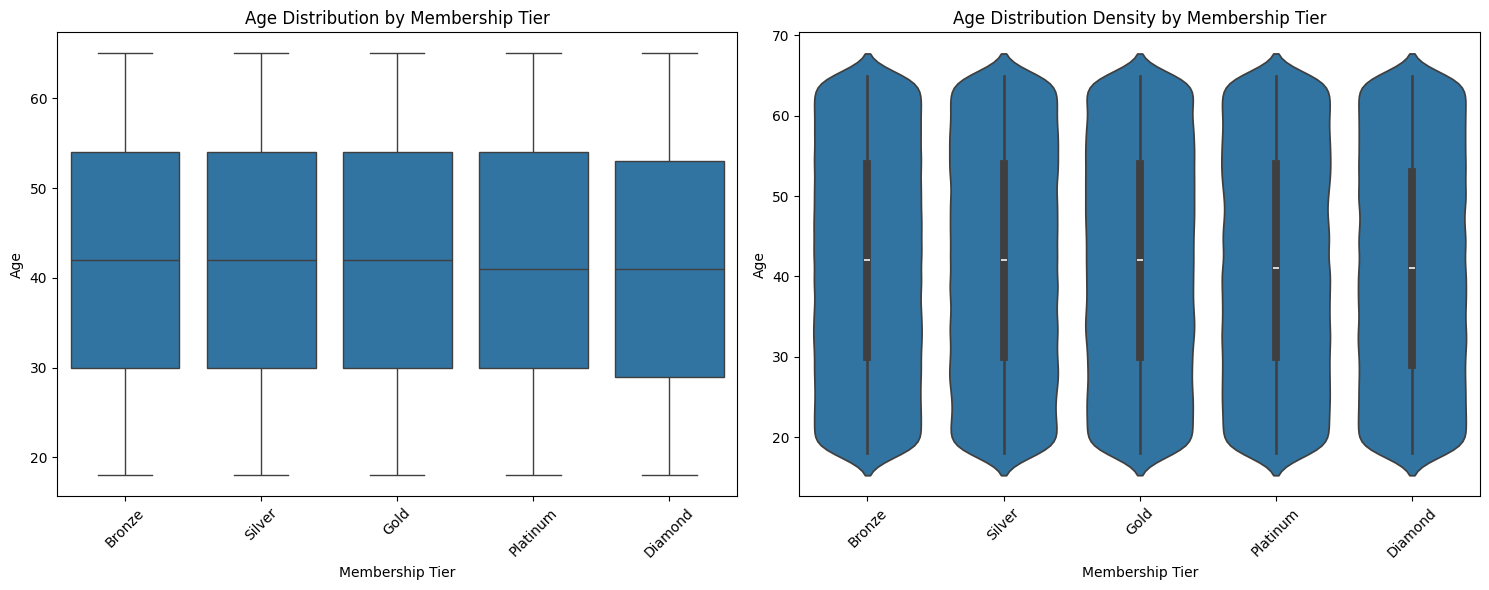


Detailed Age Percentiles by Membership Tier:
                   count   mean    std   min   25%   50%   75%   max
MembershipTier                                                      
Bronze          102863.0  41.50  13.85  18.0  30.0  42.0  54.0  65.0
Silver          102862.0  41.54  13.85  18.0  30.0  42.0  54.0  65.0
Gold            102860.0  41.60  13.82  18.0  30.0  42.0  54.0  65.0
Platinum        102862.0  41.51  13.87  18.0  30.0  41.0  54.0  65.0
Diamond         102862.0  41.46  13.87  18.0  29.0  41.0  53.0  65.0


/var/folders/_7/wbb8p5rn1jxcc1d45rrn7qqh0000gn/T/ipykernel_58804/2305607323.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  percentiles = df.groupby('MembershipTier')['Age'].describe(percentiles=[.25, .5, .75]).round(2)


In [35]:
# Calculate age statistics for each membership tier
age_stats = df.groupby('MembershipTier')['Age'].agg(['min', 'max', 'mean', 'median']).round(2)
print("\nAge Statistics by Membership Tier:")
print(age_stats)

# Create visualizations to show age distribution across tiers
plt.figure(figsize=(15, 6))

# Box plot
plt.subplot(1, 2, 1)
sns.boxplot(x='MembershipTier', y='Age', data=df)
plt.title('Age Distribution by Membership Tier')
plt.xlabel('Membership Tier')
plt.ylabel('Age')
plt.xticks(rotation=45)

# Violin plot
plt.subplot(1, 2, 2)
sns.violinplot(x='MembershipTier', y='Age', data=df)
plt.title('Age Distribution Density by Membership Tier')
plt.xlabel('Membership Tier')
plt.ylabel('Age')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Optional: Calculate the age percentiles for each tier
print("\nDetailed Age Percentiles by Membership Tier:")
percentiles = df.groupby('MembershipTier')['Age'].describe(percentiles=[.25, .5, .75]).round(2)
print(percentiles)

Sample of new Purchase History:
  BrowsingBehavior              PurchaseHistory
0           Sports                [Sports Wear]
1  Beauty & Health  [Skincare, Makeup, Perfume]
2          Fashion               [Dress, Watch]
3          Fashion                      [Jeans]
4          Fashion    [T-shirt, Jeans, Handbag]

Average number of items in Purchase History: 1.26

Most common purchased products:
Action Figures         18736
Board Games            18681
Remote Control Cars    18664
Educational Toys       18564
Puzzles                18526
Skincare               15658
Fitness Tracker        15588
Gym Equipment          15581
Hair Care              15563
Yoga Mat               15555
Name: count, dtype: int64


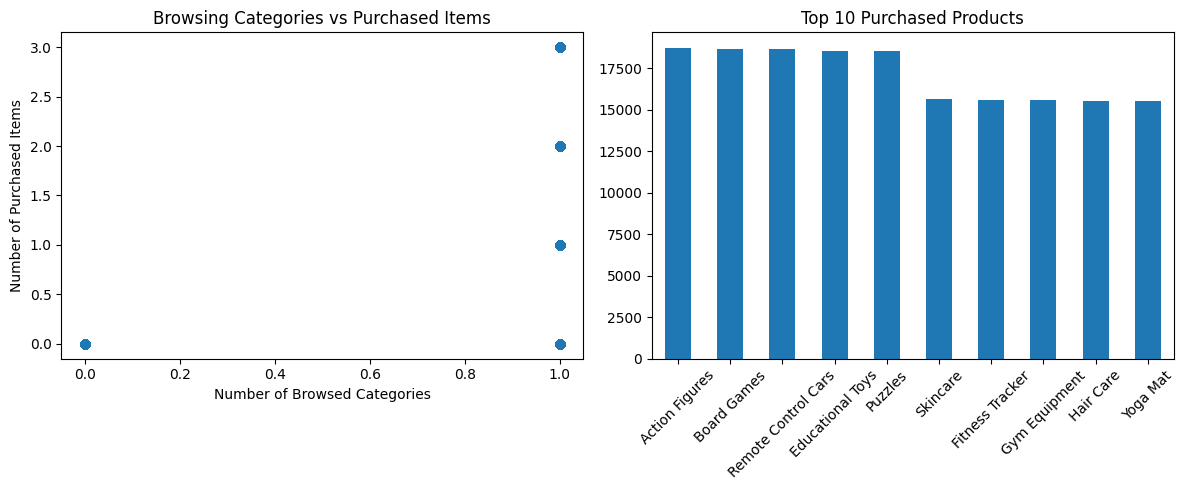

In [41]:
# Create a dictionary mapping categories to products
category_products = {
    'Electronics': ['Smartphone', 'Laptop', 'Headphones', 'Tablet', 'Smart Watch', 'Camera', 'Power Bank'],
    'Fashion': ['T-shirt', 'Jeans', 'Dress', 'Shoes', 'Handbag', 'Sunglasses', 'Watch'],
    'Home & Garden': ['Furniture', 'Bedding', 'Kitchen Appliances', 'Garden Tools', 'Home Decor', 'Lighting'],
    'Beauty & Health': ['Skincare', 'Makeup', 'Hair Care', 'Vitamins', 'Face Masks', 'Perfume'],
    'Sports': ['Running Shoes', 'Yoga Mat', 'Gym Equipment', 'Sports Wear', 'Water Bottle', 'Fitness Tracker'],
    'Books': ['Fiction', 'Non-Fiction', 'Self-Help', 'Cookbook', 'Biography', 'Academic'],
    'Toys': ['Board Games', 'Action Figures', 'Educational Toys', 'Puzzles', 'Remote Control Cars'],
    'Automotive': ['Car Accessories', 'Car Care', 'Tools', 'Car Electronics', 'Spare Parts']
}

# Function to generate purchases based on browsing category
def generate_category_purchases(browsing):
    if not browsing or browsing == '[]':
        return []
    
    purchases = []
    
    # Clean and parse the browsing string
    if isinstance(browsing, str):
        # Remove brackets and split by commas
        browsing = browsing.strip('[]').replace("'", "").split(',')
        # Clean up any whitespace
        browsing = [category.strip() for category in browsing if category.strip()]
    
    # 70% chance to make purchases from each browsed category
    for category in browsing:
        if np.random.random() < 0.7 and category in category_products:
            # Add 1-3 random products from that category
            num_products = np.random.randint(1, 4)
            category_items = np.random.choice(
                category_products[category],
                size=min(num_products, len(category_products[category])),
                replace=False
            )
            purchases.extend(category_items)
    
    return purchases

# Set random seed for reproducibility
np.random.seed(42)

# Generate new PurchaseHistory
df['PurchaseHistory'] = df['BrowsingBehavior'].apply(generate_category_purchases)

# Display some statistics
print("Sample of new Purchase History:")
print(df[['BrowsingBehavior', 'PurchaseHistory']].head())

print("\nAverage number of items in Purchase History:", 
      df['PurchaseHistory'].apply(len).mean().round(2))

# Analyze purchase patterns
print("\nMost common purchased products:")
all_purchases = [item for sublist in df['PurchaseHistory'] for item in sublist]
purchase_counts = pd.Series(all_purchases).value_counts().head(10)
print(purchase_counts)

# Visualize the relationship between browsing and purchasing
plt.figure(figsize=(12, 5))

# Plot 1: Browsing vs Purchase counts
plt.subplot(1, 2, 1)
browsing_lengths = df['BrowsingBehavior'].apply(lambda x: len(x.strip('[]').split(',')) if x != '[]' else 0)
purchase_lengths = df['PurchaseHistory'].apply(len)
plt.scatter(browsing_lengths, purchase_lengths, alpha=0.5)
plt.xlabel('Number of Browsed Categories')
plt.ylabel('Number of Purchased Items')
plt.title('Browsing Categories vs Purchased Items')

# Plot 2: Most common purchases
plt.subplot(1, 2, 2)
purchase_counts.plot(kind='bar')
plt.title('Top 10 Purchased Products')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [45]:
from sklearn.preprocessing import LabelEncoder

# Initialize separate LabelEncoders for each column
location_encoder = LabelEncoder()
gender_encoder = LabelEncoder()
membership_encoder = LabelEncoder()

# Fit and transform each column with its own encoder
df['Location_Encoded'] = location_encoder.fit_transform(df['Location'])
df['Gender_Encoded'] = gender_encoder.fit_transform(df['Gender']) 
df['MembershipTier_Encoded'] = membership_encoder.fit_transform(df['MembershipTier'])


# Display unique values mapping for each column
print("\nUnique values mapping:")

print("\nLocation:")
for i, label in enumerate(location_encoder.classes_):
    print(f"{label}: {i}")
    
print("\nGender:")
for i, label in enumerate(gender_encoder.classes_):
    print(f"{label}: {i}")
    
print("\nMembershipTier:")
for i, label in enumerate(membership_encoder.classes_):
    print(f"{label}: {i}")




Unique values mapping:

Location:
Berlin: 0
Chicago: 1
Houston: 2
London: 3
Los Angeles: 4
New York: 5
Phoenix: 6
Sydney: 7
Toronto: 8

Gender:
Female: 0
Male: 1
Non-binary: 2
nan: 3

MembershipTier:
Bronze: 0
Diamond: 1
Gold: 2
Platinum: 3
Silver: 4


In [46]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Select numerical columns for scaling
numerical_columns = ['Age', 'AmountSpent']

# Create new scaled columns
scaled_columns = scaler.fit_transform(df[numerical_columns])

# Create a new dataframe with scaled values
scaled_df = pd.DataFrame(scaled_columns, columns=[f'{col}_Scaled' for col in numerical_columns])



In [49]:
df = pd.concat([df, scaled_df], axis=1)

In [50]:
df

,CustomerID,Name,Email,Gender,Location,BrowsingBehavior,AmountSpent,MembershipTier,Age,PurchaseHistory,Location_Encoded,Gender_Encoded,MembershipTier_Encoded,Age_Scaled,AmountSpent_Scaled
0,439415,Taylor Brown,iyevwvc@xpvsc.com,Female,Chicago,Sports,455.77,Bronze,56,[Sports Wear],1,0,0,1.045122,-1.463687
1,391407,Casey Garcia,rcckyzo@zxksq.com,Female,Chicago,Beauty & Health,51.28,Bronze,46,"[Skincare, Makeup, Perfume]",1,0,0,0.323281,-1.752224
2,547997,Casey Martinez,dymvmaj@cgiux.com,Non-binary,Berlin,Fashion,3651.59,Platinum,32,"[Dress, Watch]",0,2,3,-0.687296,0.816002
3,814863,John Johnson,jqjtror@pgeng.com,Female,Los Angeles,Fashion,4504.26,Diamond,60,[Jeans],4,0,1,1.333858,1.424241
4,769435,Morgan Brown,uhldvtd@wlntn.com,Non-binary,Toronto,Fashion,3921.94,Platinum,25,"[T-shirt, Jeans, Handbag]",8,2,3,-1.192584,1.008852
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
514304,207951,Morgan Davis,lvelckx@eoski.com,Male,Berlin,Sports,150.92,Bronze,60,[Fitness Tracker],0,1,0,1.333858,-1.681147
514305,932761,Jane Miller,lrqudun@mwyrw.com,Female,Sydney,Sports,4688.65,Diamond,61,[Running Shoes],7,0,1,1.406042,1.555773
514306,792017,Taylor Williams,fplgbcw@oimoc.com,Male,New York,Fashion,1254.62,Silver,31,[],5,1,4,-0.759480,-0.893840
514307,457370,Chris Martinez,unknown@example.com,Female,Los Angeles,Books,2098.87,Silver,47,"[Fiction, Biography]",4,0,4,0.395465,-0.291607


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 514309 entries, 0 to 514308
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype   
---  ------                  --------------   -----   
 0   CustomerID              514309 non-null  int64   
 1   Name                    514309 non-null  object  
 2   Email                   514309 non-null  object  
 3   Gender                  462743 non-null  object  
 4   Location                514309 non-null  object  
 5   BrowsingBehavior        514309 non-null  object  
 6   AmountSpent             514309 non-null  float64 
 7   MembershipTier          514309 non-null  category
 8   Age                     514309 non-null  int64   
 9   PurchaseHistory         514309 non-null  object  
 10  Location_Encoded        514309 non-null  int64   
 11  Gender_Encoded          514309 non-null  int64   
 12  MembershipTier_Encoded  514309 non-null  int64   
 13  Age_Scaled              514309 non-null  float64 
 14  Amou

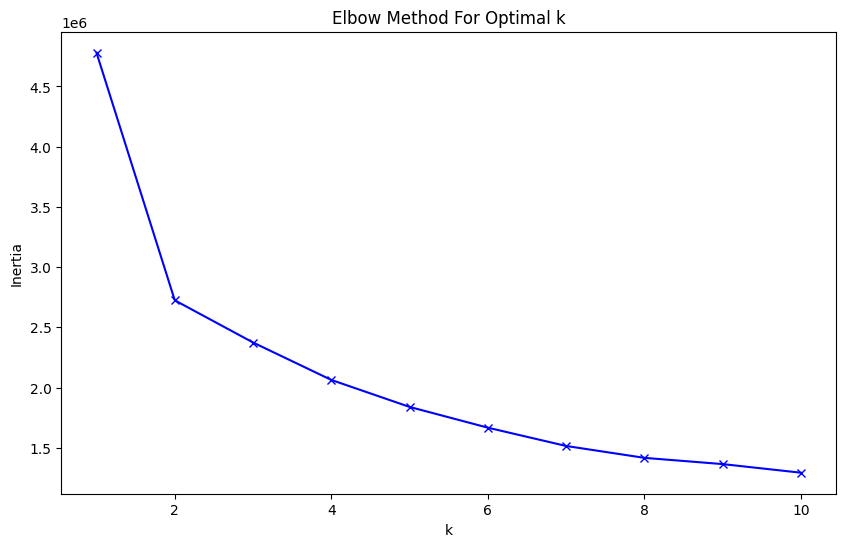


Cluster Analysis:
           Age  AmountSpent MembershipTier Location      Gender
Cluster                                                        
0        41.50       543.63         Bronze  Phoenix  Non-binary
1        41.49      2505.53         Bronze  Chicago        Male
2        41.52      2995.14         Silver  Phoenix        Male
3        41.59      2903.45         Silver   London      Female


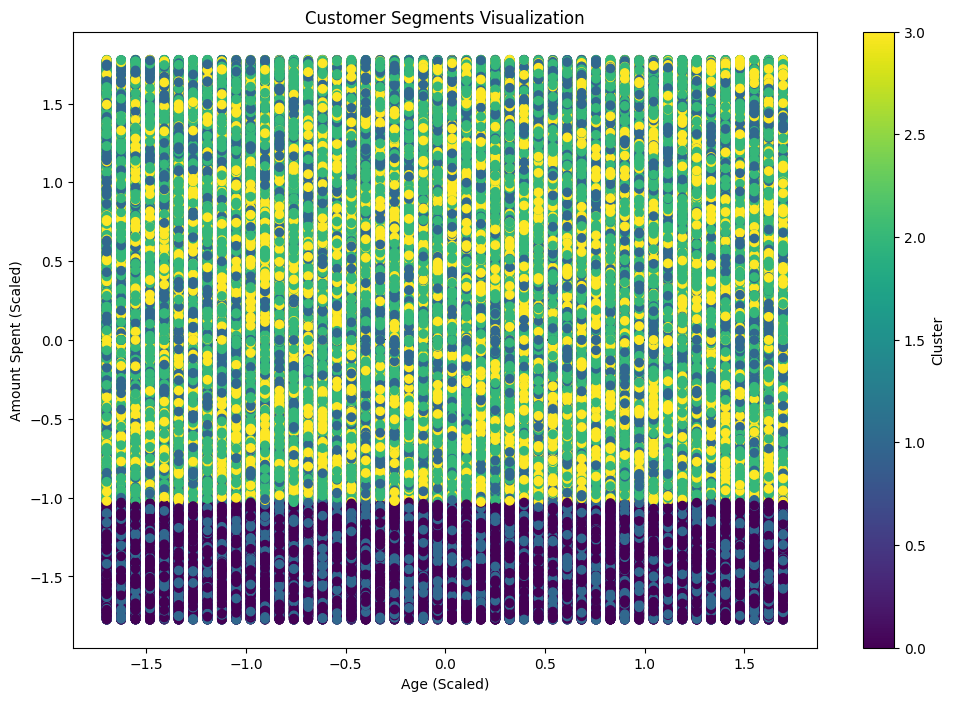

In [61]:
# Split features for clustering
X = df[['Age_Scaled', 'AmountSpent_Scaled', 'MembershipTier_Encoded', 'Location_Encoded', 'Gender_Encoded']]

# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

# Initialize and train KMeans model
from sklearn.cluster import KMeans

# Try different numbers of clusters
inertias = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train)
    inertias.append(kmeans.inertia_)

# Plot elbow curve to find optimal number of clusters
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(K, inertias, 'bx-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

# Based on elbow curve, train final model with optimal k
optimal_k = 4 # Adjust this based on elbow curve
final_model = KMeans(n_clusters=optimal_k, random_state=42)
final_model.fit(X_train)

# Get cluster assignments for both train and test sets
train_clusters = final_model.predict(X_train)
test_clusters = final_model.predict(X_test)

# Add cluster labels to original dataframe
df['Cluster'] = final_model.predict(X)

# Analyze clusters
cluster_analysis = df.groupby('Cluster').agg({
    'Age': 'mean',
    'AmountSpent': 'mean',
    'MembershipTier': lambda x: x.mode()[0],
    'Location': lambda x: x.mode()[0],
    'Gender': lambda x: x.mode()[0]
}).round(2)

print("\nCluster Analysis:")
print(cluster_analysis)

# Visualize clusters (2D projection using Age and AmountSpent)
plt.figure(figsize=(12, 8))
scatter = plt.scatter(df['Age_Scaled'], df['AmountSpent_Scaled'], 
                     c=df['Cluster'], cmap='viridis')
plt.xlabel('Age (Scaled)')
plt.ylabel('Amount Spent (Scaled)')
plt.title('Customer Segments Visualization')
plt.colorbar(scatter, label='Cluster')
plt.show()



Detailed Cluster Analysis:

Cluster Sizes:
Cluster
2    183007
1    148875
3    114161
0     68266
Name: count, dtype: int64

Cluster Characteristics:

Cluster 0:
Size: 68266 customers
Age range: 18 - 65 years
Average age: 41.5 years
Spending range: $20.01 - $1065.29
Average spending: $543.63
Top membership tiers: {'Bronze': 68266, 'Silver': 0, 'Gold': 0}
Gender distribution: {'Non-binary': 20601, 'Male': 20546, 'Female': 20201}
Top locations: {'Phoenix': 11530, 'London': 11453, 'Los Angeles': 11446}

Cluster 1:
Size: 148875 customers
Age range: 18 - 65 years
Average age: 41.49 years
Spending range: $20.03 - $4999.97
Average spending: $2505.53
Top membership tiers: {'Bronze': 34597, 'Diamond': 34428, 'Gold': 34235}
Gender distribution: {'Male': 45032, 'Non-binary': 44614, 'Female': 44340}
Top locations: {'Chicago': 57368, 'Berlin': 57201, 'Houston': 34306}

Cluster 2:
Size: 183007 customers
Age range: 18 - 65 years
Average age: 41.52 years
Spending range: $1065.3 - $4999.99
Average sp

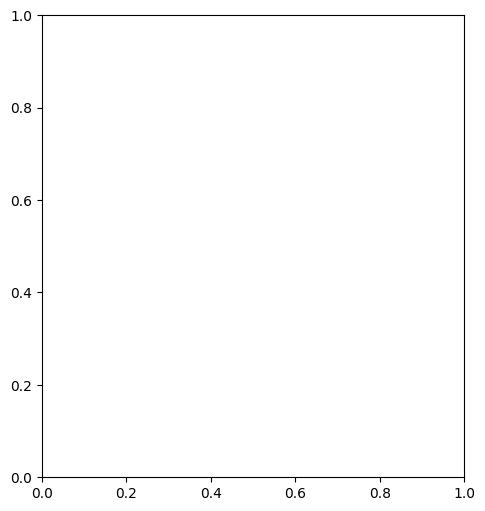

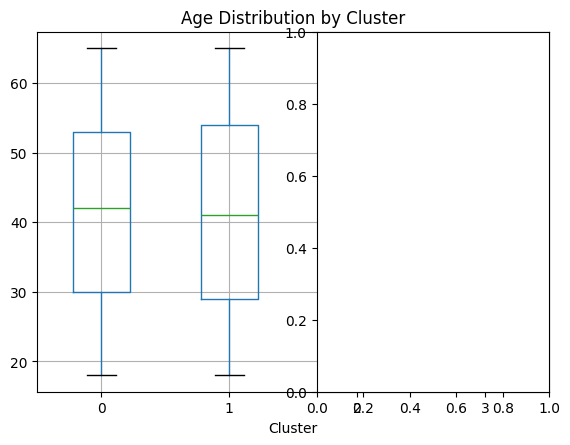

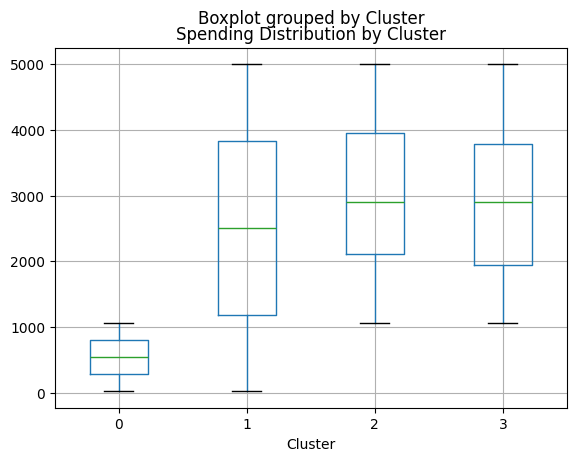

<Figure size 1200x600 with 0 Axes>

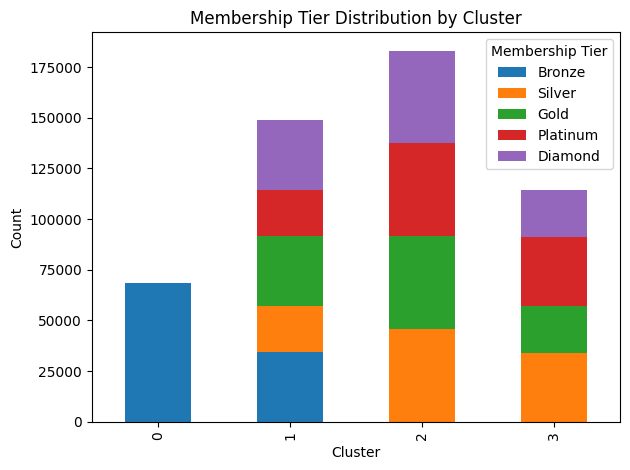

In [62]:
# Create a more detailed analysis of each cluster
cluster_details = df.groupby('Cluster').agg({
    'Age': ['mean', 'min', 'max'],
    'AmountSpent': ['mean', 'min', 'max'],
    'MembershipTier': lambda x: x.value_counts().to_dict(),
    'Gender': lambda x: x.value_counts().to_dict(),
    'Location': lambda x: x.value_counts().to_dict()
}).round(2)

print("\nDetailed Cluster Analysis:")
print("\nCluster Sizes:")
print(df['Cluster'].value_counts())

print("\nCluster Characteristics:")
for cluster in range(optimal_k):
    print(f"\nCluster {cluster}:")
    print(f"Size: {len(df[df['Cluster'] == cluster])} customers")
    print(f"Age range: {cluster_details[('Age', 'min')][cluster]} - {cluster_details[('Age', 'max')][cluster]} years")
    print(f"Average age: {cluster_details[('Age', 'mean')][cluster]} years")
    print(f"Spending range: ${cluster_details[('AmountSpent', 'min')][cluster]} - ${cluster_details[('AmountSpent', 'max')][cluster]}")
    print(f"Average spending: ${cluster_details[('AmountSpent', 'mean')][cluster]}")
    print("Top membership tiers:", dict(sorted(cluster_details[('MembershipTier', '<lambda>')][cluster].items(), key=lambda x: x[1], reverse=True)[:3]))
    print("Gender distribution:", dict(sorted(cluster_details[('Gender', '<lambda>')][cluster].items(), key=lambda x: x[1], reverse=True)[:3]))
    print("Top locations:", dict(sorted(cluster_details[('Location', '<lambda>')][cluster].items(), key=lambda x: x[1], reverse=True)[:3]))

# Visualize age distribution across clusters
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
df.boxplot(column='Age', by='Cluster')
plt.title('Age Distribution by Cluster')
plt.suptitle('')

# Visualize spending distribution across clusters
plt.subplot(1, 2, 2)
df.boxplot(column='AmountSpent', by='Cluster')
plt.title('Spending Distribution by Cluster')
plt.show()

# Visualize membership tier distribution across clusters
plt.figure(figsize=(12, 6))
membership_by_cluster = pd.crosstab(df['Cluster'], df['MembershipTier'])
membership_by_cluster.plot(kind='bar', stacked=True)
plt.title('Membership Tier Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.legend(title='Membership Tier')
plt.tight_layout()
plt.show()